In [86]:


import pandas as pd
import numpy as np

In [87]:
data=pd.read_csv("WineQT.csv")

In [88]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
set(data.quality)

{3, 4, 5, 6, 7, 8}

In [91]:
data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


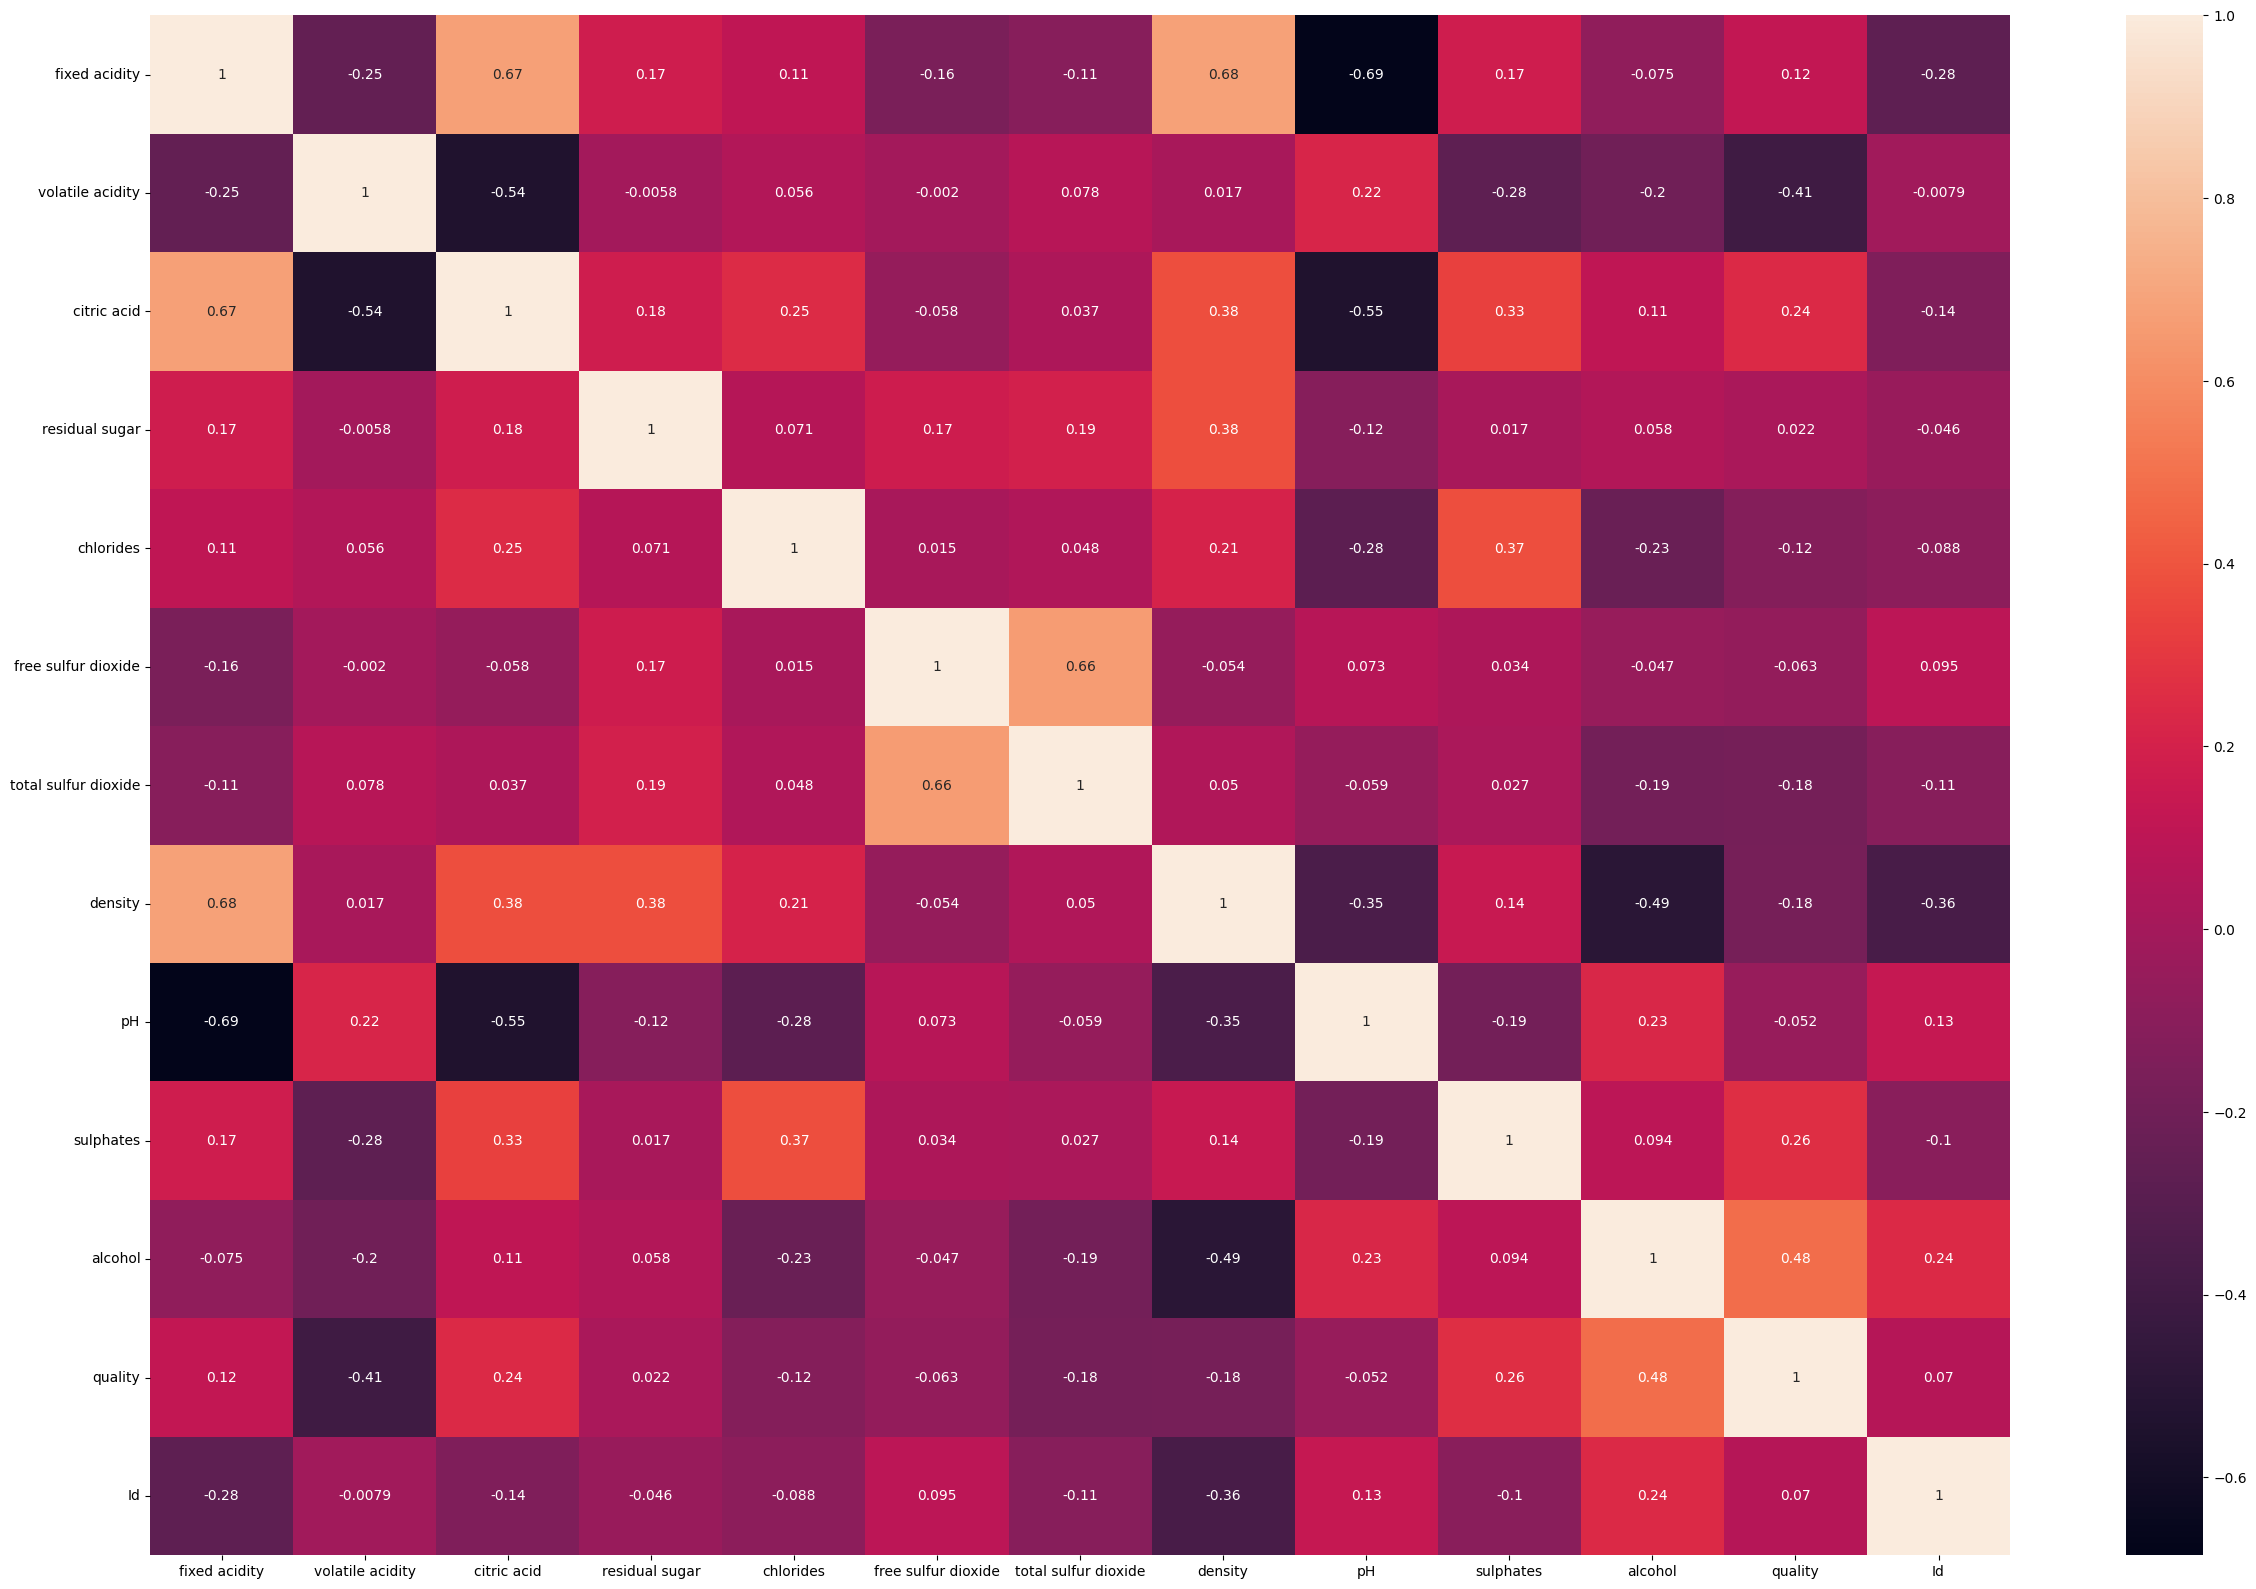

In [92]:
plt.figure(figsize=(30,20))
corr=data.corr()
sns.heatmap(corr,annot=True)
plt.savefig("heatmap.png")
plt.show()


In [93]:
from scipy import stats
z=np.abs(stats.zscore(data))
print(z)

[[0.52157961 0.93933222 1.36502663 ... 0.96338181 0.81572437 1.73561799]
 [0.29259344 1.94181282 1.36502663 ... 0.59360107 0.81572437 1.73346186]
 [0.29259344 1.27349242 1.16156762 ... 0.59360107 0.81572437 1.73130573]
 ...
 [1.20853813 0.38239855 0.9581086  ... 0.05351522 0.81572437 1.70125196]
 [1.38027776 0.10393172 0.8563791  ... 0.70063152 0.42578423 1.70340809]
 [1.38027776 0.6330187  0.75464959 ... 0.22382033 0.81572437 1.70772035]]


In [94]:
print(np.where(z>3))

(array([  11,   13,   30,   31,   32,   59,   61,   64,   75,   75,   87,
         88,   96,   98,  103,  103,  103,  103,  114,  115,  129,  142,
        161,  161,  167,  170,  171,  182,  182,  200,  230,  231,  240,
        244,  249,  272,  275,  275,  278,  278,  287,  289,  311,  311,
        324,  329,  339,  339,  348,  366,  368,  388,  397,  397,  399,
        399,  407,  419,  421,  424,  430,  452,  453,  454,  460,  460,
        462,  462,  462,  485,  490,  490,  493,  514,  520,  538,  557,
        572,  589,  597,  598,  627,  627,  644,  648,  654,  655,  690,
        714,  738,  738,  756,  760,  760,  761,  761,  787,  831,  871,
        890,  898,  898,  914,  915,  919,  922,  922,  931,  933,  934,
        934,  935,  965,  971,  973,  973,  975,  975, 1022, 1022, 1022,
       1046, 1051, 1051, 1053, 1053, 1055, 1066, 1074, 1111, 1111, 1111,
       1122]), array([ 9,  4,  4,  9,  8,  9,  9,  9,  4,  9,  1,  1, 10, 10,  2,  4,  8,
        9,  3,  3,  4,  1,  4,  9

In [95]:
new_data=data[(z<3).all(axis=1)]

In [96]:
new_data.shape

(1041, 13)

In [97]:
data.shape

(1143, 13)

In [98]:
from sklearn.model_selection import train_test_split


X=new_data.drop(columns=["quality"],axis=1)
y=new_data["quality"]

In [99]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,4


In [100]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1138,6
1139,6
1140,5
1141,6


In [101]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [102]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

In [103]:
rf.fit(X_train,y_train)

RandomForestClassifier()

In [104]:
y_pred=rf.predict(X_test)

In [105]:
y_pred

array([5, 5, 5, 5, 7, 5, 6, 6, 6, 5, 6, 5, 5, 6, 7, 5, 5, 5, 6, 6, 5, 5,
       6, 6, 5, 5, 6, 6, 7, 5, 6, 6, 6, 6, 5, 6, 5, 5, 5, 5, 6, 7, 5, 6,
       5, 5, 6, 5, 6, 5, 5, 5, 5, 5, 5, 6, 6, 5, 6, 5, 6, 6, 7, 5, 5, 6,
       5, 7, 6, 7, 5, 6, 6, 5, 5, 5, 5, 6, 5, 7, 6, 6, 6, 6, 6, 7, 5, 6,
       5, 5, 7, 5, 6, 7, 5, 5, 6, 6, 6, 5, 5, 5, 5, 5, 6, 5, 7, 5, 6, 5,
       7, 8, 6, 6, 5, 5, 6, 6, 5, 5, 6, 6, 7, 6, 7, 5, 6, 6, 5, 5, 6, 6,
       6, 6, 5, 5, 6, 6, 5, 5, 5, 5, 6, 5, 5, 6, 6, 6, 5, 6, 5, 6, 5, 6,
       7, 5, 7, 5, 6, 6, 6, 6, 6, 6, 5, 6, 5, 6, 5, 6, 6, 5, 6, 6, 5, 5,
       6, 6, 5, 6, 5, 6, 6, 6, 6, 6, 5, 5, 5, 6, 5, 7, 5, 6, 7, 7, 6, 7,
       7, 6, 6, 6, 5, 5, 5, 6, 5, 5, 7, 5, 6, 7, 6, 6, 6, 5, 5, 5, 6, 5,
       5, 5, 5, 7, 5, 7, 5, 5, 6, 5, 7, 6, 6, 5, 6, 5, 5, 7, 6, 5, 5, 5,
       6, 5, 5, 5, 5, 5, 5, 7, 6, 6, 6, 5, 5, 6, 6, 5, 5, 6, 6, 5, 5, 5,
       7, 5, 6, 6, 7, 6, 6, 5, 7, 5, 6, 6, 5, 5, 6, 6, 5, 6, 5, 6, 5, 6,
       6, 5, 6, 6, 5, 5, 6, 6, 7, 5, 6, 6, 6, 5, 6,

In [106]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.6773162939297125

[Text(0.46275770616493195, 0.9722222222222222, 'x[1] <= 0.405\ngini = 0.644\nsamples = 471\nvalue = [18, 295, 301, 102, 12]'),
 Text(0.12394915932746196, 0.9166666666666666, 'x[2] <= 0.315\ngini = 0.666\nsamples = 137\nvalue = [3, 38, 95, 74, 9]'),
 Text(0.29335343274619696, 0.9444444444444444, 'True  '),
 Text(0.041633306645316254, 0.8611111111111112, 'x[0] <= 8.25\ngini = 0.614\nsamples = 27\nvalue = [0, 17, 16, 3, 2]'),
 Text(0.03522818254603683, 0.8055555555555556, 'x[10] <= 9.45\ngini = 0.607\nsamples = 23\nvalue = [0, 17, 10, 3, 2]'),
 Text(0.028823058446757407, 0.75, 'gini = 0.0\nsamples = 7\nvalue = [0, 9, 0, 0, 0]'),
 Text(0.041633306645316254, 0.75, 'x[8] <= 3.425\ngini = 0.665\nsamples = 16\nvalue = [0, 8, 10, 3, 2]'),
 Text(0.025620496397117692, 0.6944444444444444, 'x[3] <= 1.85\ngini = 0.684\nsamples = 10\nvalue = [0, 7, 3, 3, 2]'),
 Text(0.012810248198558846, 0.6388888888888888, 'x[8] <= 3.305\ngini = 0.611\nsamples = 4\nvalue = [0, 0, 3, 2, 1]'),
 Text(0.0064051240992794

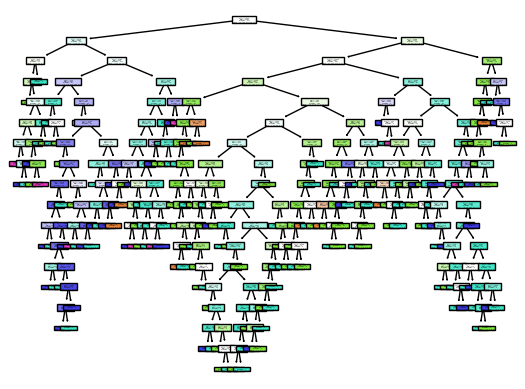

In [107]:
from sklearn import tree
tree.plot_tree(rf.estimators_[0],filled=True)

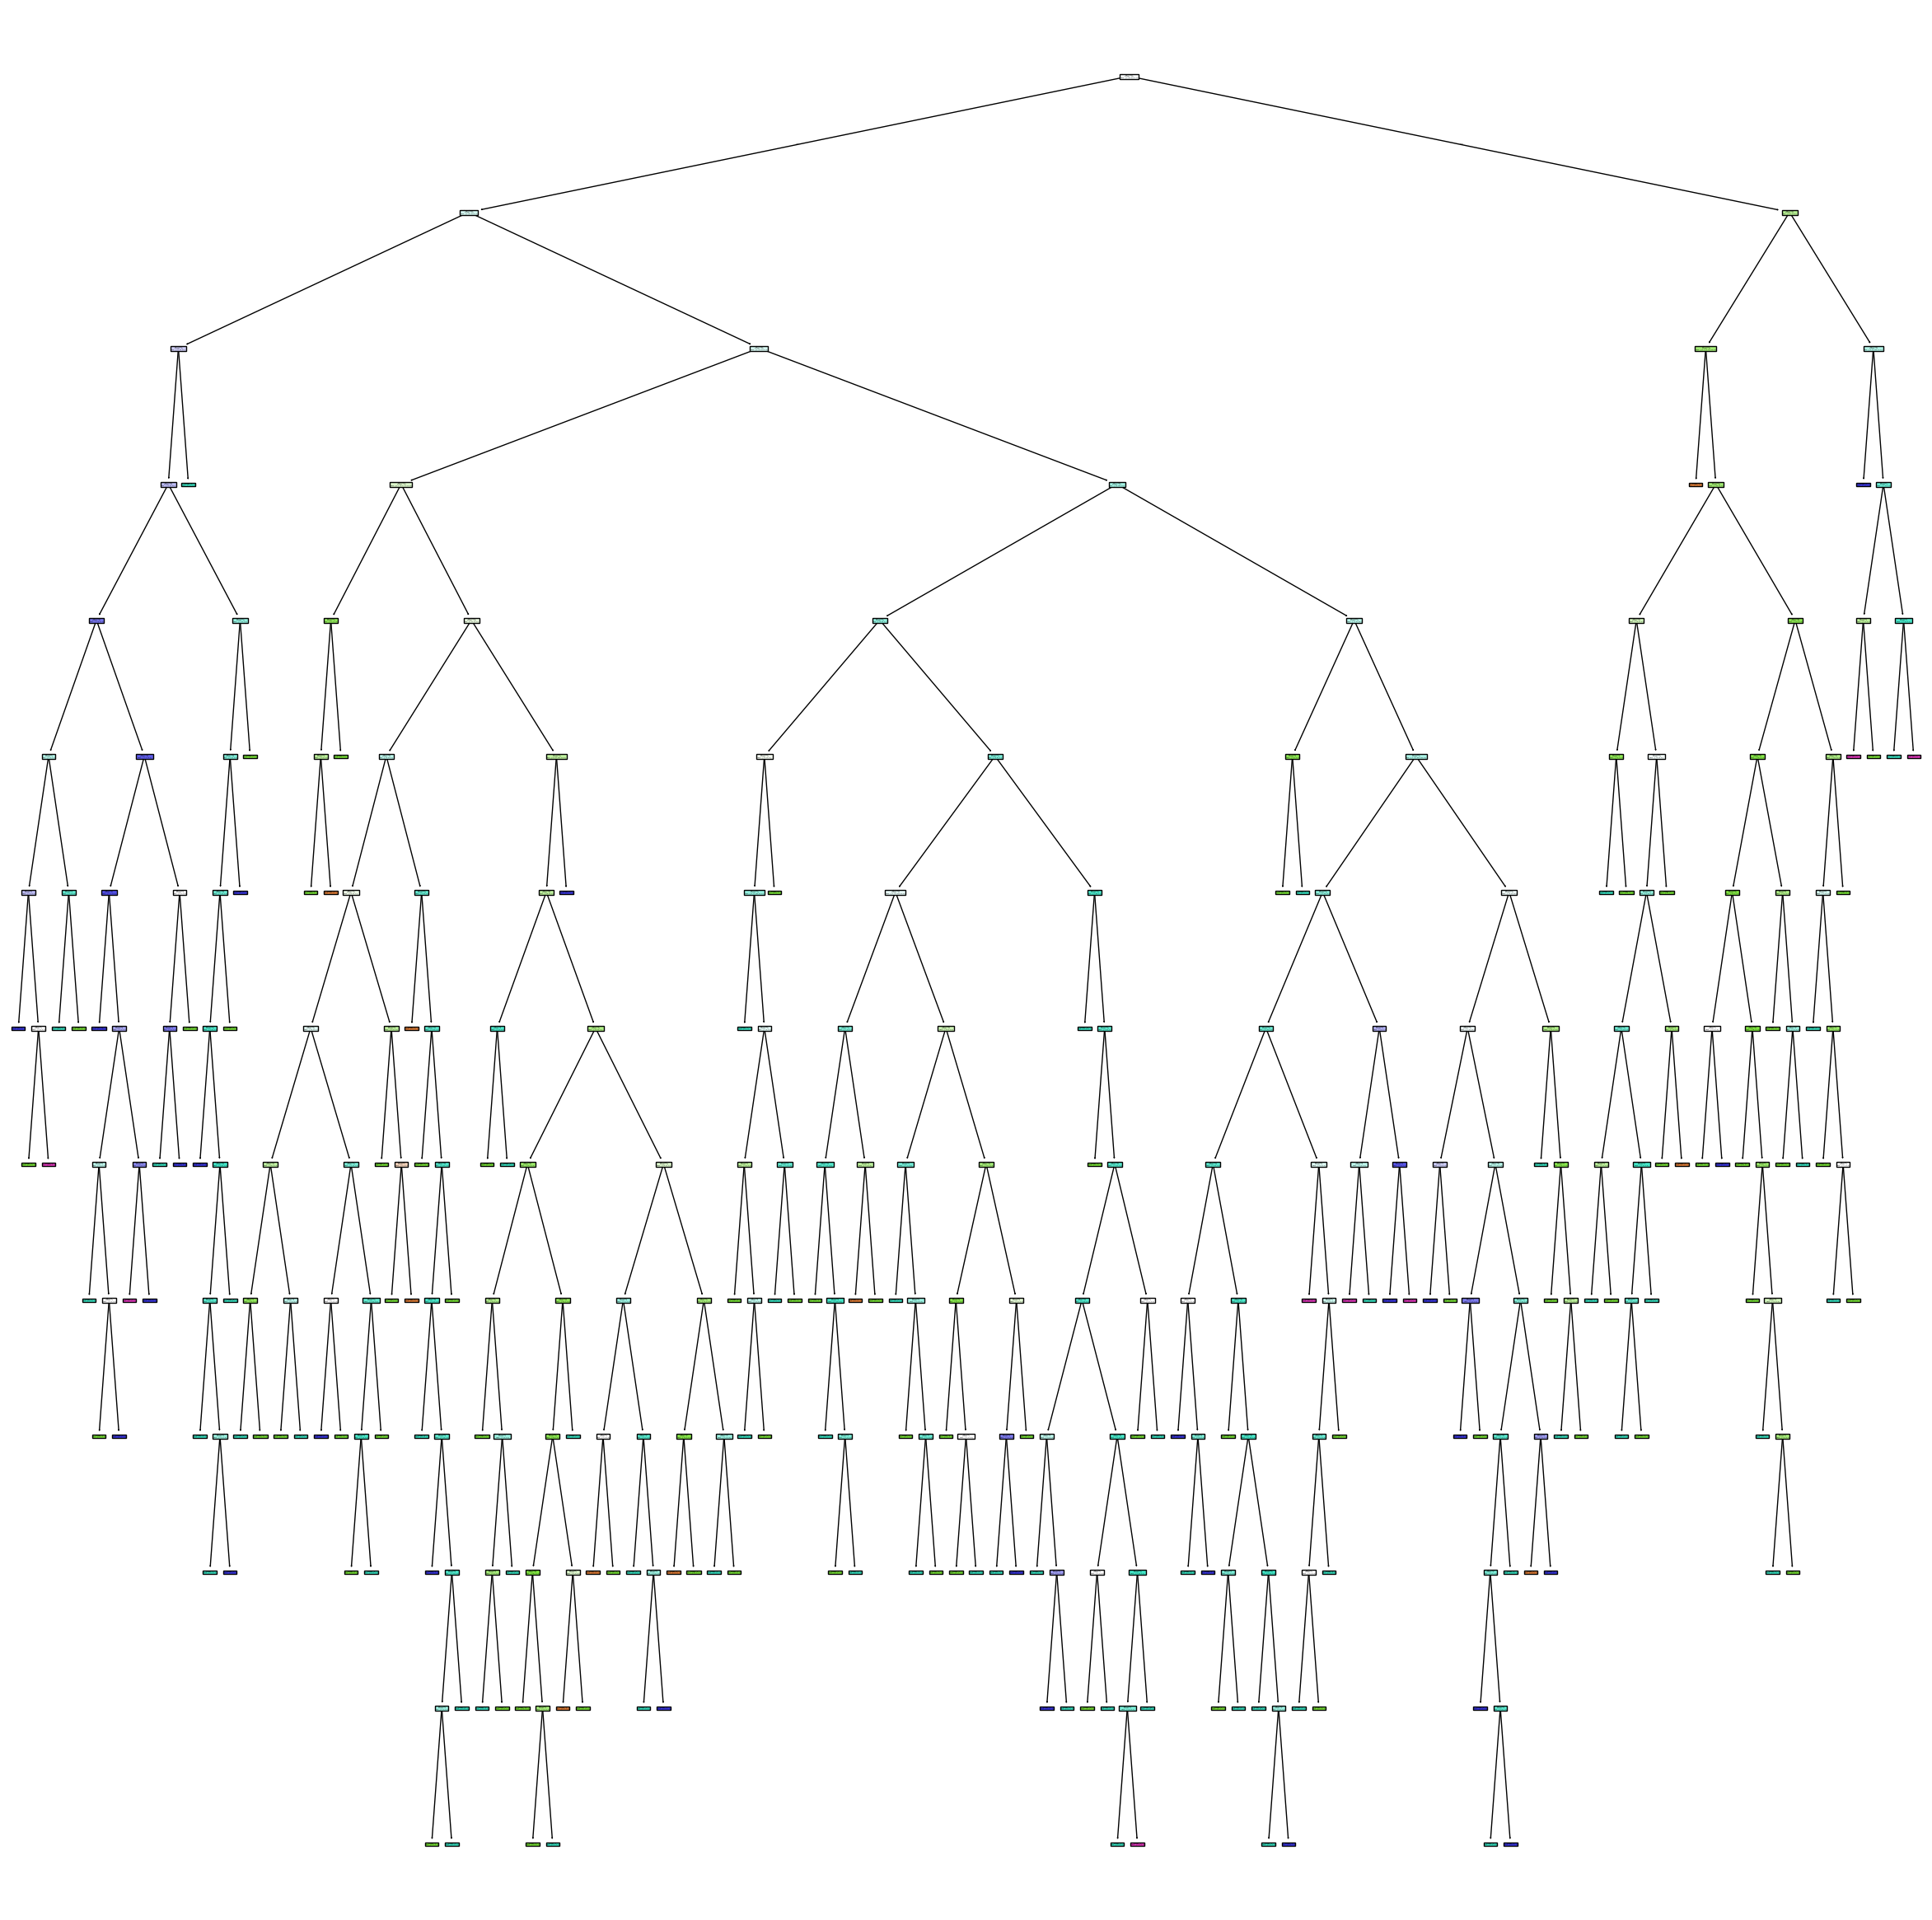

In [108]:
plt.figure(figsize=(30,30))
for i in range(len(rf.estimators_)):
    tree.plot_tree(rf.estimators_[i],filled=True,feature_names=X.columns)